# Support Ticket Data Audit

Audit the registry-built canonical dataset, the downstream SFT and eval manifests, and the composition artifacts that describe provenance, label balance, null handling, and synthetic share.

In [1]:
from collections import Counter
from pathlib import Path
from statistics import mean
import json
import sys

def resolve_repo_root() -> Path:
    candidates = [
        Path.cwd(),
        Path('/content/drive/MyDrive/json-ft-source'),
    ]
    for candidate in candidates:
        if (candidate / 'src' / 'json_ft').exists():
            return candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'json_ft').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root containing src/json_ft')

repo_root = resolve_repo_root()
sys.path.insert(0, str(repo_root / 'src'))

from json_ft.dataset_adapters import adapt_source_record, eval_manifest_record, messages_record, prompt_completion_record
from json_ft.utils import load_yaml, read_json, read_jsonl

canonical_path = repo_root / 'data' / 'manifests' / 'support_tickets_canonical.jsonl'
summary_path = repo_root / 'data' / 'manifests' / 'support_tickets_dataset_build_summary.json'
composition_path = repo_root / 'artifacts' / 'metrics' / 'support_tickets_dataset_composition.json'
model_config = load_yaml(repo_root / 'configs' / 'model.yaml')

rows = read_jsonl(canonical_path)
samples = [adapt_source_record(row, 'json_extraction') for row in rows]
summary = read_json(summary_path)
composition = read_json(composition_path)
base_model = model_config['base_model']['tokenizer_name_or_path']

print(f'Repo root: {repo_root}')
print(f'Canonical rows: {len(samples)}')
print(f'Build profile: {summary["profile"]}')
print(f'Base tokenizer: {base_model}')
print('Active sources:', summary.get('active_sources', []))
print('Fixture sources:', summary.get('fixture_sources', []))

Repo root: /content/drive/MyDrive/json-ft-source
Canonical rows: 83611
Build profile: full
Base tokenizer: Qwen/Qwen2.5-1.5B-Instruct
Active sources: ['synthetic_support_tickets_v1', 'console_ai_it_helpdesk_synthetic_tickets', 'prady06_customer_support_tickets', 'cfpb_consumer_complaints', 'synthetic_hardening_v1']
Fixture sources: []


In [2]:
split_counts = Counter(sample.split.value for sample in samples)
source_counts = Counter(sample.source_dataset for sample in samples)
issue_counts = Counter(sample.target.issue_category.value for sample in samples)
priority_counts = Counter(sample.target.priority.value for sample in samples)
product_counts = Counter(sample.target.product_area.value for sample in samples)
sentiment_counts = Counter(sample.target.sentiment.value for sample in samples)

print('Split counts:', dict(sorted(split_counts.items())))
print('Source counts:', dict(sorted(source_counts.items())))
print('Resolved source locations:', json.dumps(summary.get('resolved_source_locations', {}), indent=2, sort_keys=True))
print('Issue category counts:', dict(sorted(issue_counts.items())))
print('Priority counts:', dict(sorted(priority_counts.items())))
print('Product area counts:', dict(sorted(product_counts.items())))
print('Sentiment counts:', dict(sorted(sentiment_counts.items())))

Split counts: {'eval': 12450, 'train': 71161}
Source counts: {'console_ai_it_helpdesk_synthetic_tickets': 500, 'prady06_customer_support_tickets': 61763, 'synthetic_hardening_v1': 21341, 'synthetic_support_tickets_v1': 7}
Resolved source locations: {
  "cfpb_consumer_complaints": "/content/drive/MyDrive/json-ft-runs/raw-data/cfpb_consumer_complaints.csv",
  "console_ai_it_helpdesk_synthetic_tickets": "Console-AI/IT-helpdesk-synthetic-tickets",
  "prady06_customer_support_tickets": "Prady06/customer-support-tickets",
  "synthetic_hardening_v1": "generated://synthetic_hardening_v1",
  "synthetic_support_tickets_v1": "/content/drive/MyDrive/json-ft-source/data/fixtures/support_tickets.jsonl"
}
Issue category counts: {'account_access': 9091, 'billing': 7115, 'feature_request': 13427, 'general_question': 1062, 'integration': 4783, 'other': 26192, 'technical_bug': 21941}
Priority counts: {'high': 28657, 'low': 18349, 'medium': 30292, 'urgent': 6313}
Product area counts: {'account_portal': 39

In [3]:
total = len(samples)
null_stats = {
    'customer.name': sum(1 for sample in samples if sample.target.customer.name is None) / total,
    'customer.account_id': sum(1 for sample in samples if sample.target.customer.account_id is None) / total,
    'customer.plan_tier': sum(1 for sample in samples if sample.target.customer.plan_tier is None) / total,
}
synthetic_count = sum(1 for sample in samples if sample.metadata.get('synthetic', False))

print('Percent null per nullable field:')
for field, value in sorted(null_stats.items()):
    print(f'  {field}: {value:.1%}')
print(f'Synthetic rows: {synthetic_count}/{total} ({synthetic_count/total:.1%})')
print('Source dominance share:', summary['source_dominance_share'])

Percent null per nullable field:
  customer.account_id: 100.0%
  customer.name: 97.1%
  customer.plan_tier: 30.2%
Synthetic rows: 21348/83611 (25.5%)
Source dominance share: {'console_ai_it_helpdesk_synthetic_tickets': 0.006, 'prady06_customer_support_tickets': 0.7387, 'synthetic_hardening_v1': 0.2552, 'synthetic_support_tickets_v1': 0.0001}


Summary length chars: {'min': 3, 'max': 140, 'avg': 54.63}
Prompt length chars: {'min': 968, 'max': 4740, 'avg': 1483.14}
Messages length chars: {'min': 1252, 'max': 5088, 'avg': 1816.06}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Prompt token lengths: {'min': 208, 'max': 1610, 'avg': 318.12}


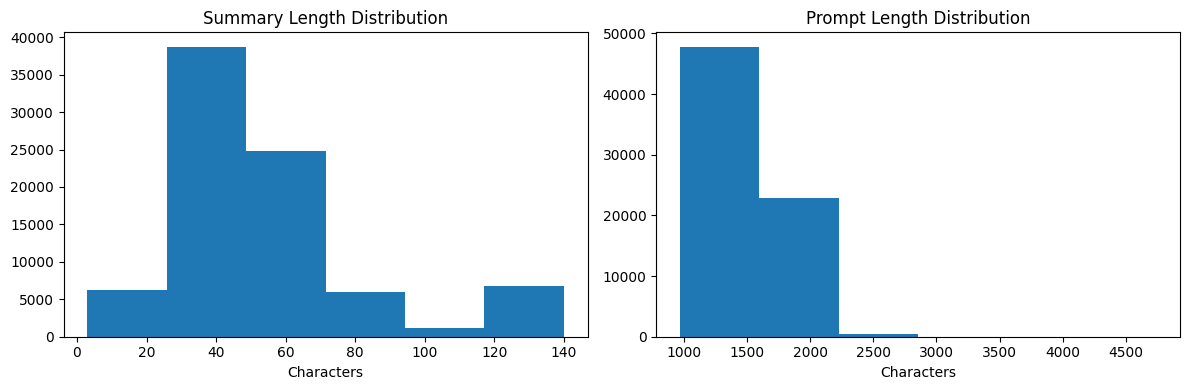

In [4]:
summary_lengths = [len(sample.target.summary) for sample in samples]
prompt_lengths = [len(prompt_completion_record(sample)['prompt']) for sample in samples if sample.split.value == 'train']
message_lengths = [sum(len(message['content']) for message in messages_record(sample)['messages']) for sample in samples if sample.split.value == 'train']

print('Summary length chars:', {'min': min(summary_lengths), 'max': max(summary_lengths), 'avg': round(mean(summary_lengths), 2)})
print('Prompt length chars:', {'min': min(prompt_lengths), 'max': max(prompt_lengths), 'avg': round(mean(prompt_lengths), 2)})
print('Messages length chars:', {'min': min(message_lengths), 'max': max(message_lengths), 'avg': round(mean(message_lengths), 2)})

try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    token_lengths = [len(tokenizer(prompt_completion_record(sample)['prompt'])['input_ids']) for sample in samples if sample.split.value == 'train']
    print('Prompt token lengths:', {'min': min(token_lengths), 'max': max(token_lengths), 'avg': round(mean(token_lengths), 2)})
except Exception as exc:
    token_lengths = []
    print('Skipping tokenizer-based prompt length audit:', exc)

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(summary_lengths, bins=min(6, len(summary_lengths)))
    axes[0].set_title('Summary Length Distribution')
    axes[0].set_xlabel('Characters')
    axes[1].hist(prompt_lengths, bins=min(6, len(prompt_lengths)))
    axes[1].set_title('Prompt Length Distribution')
    axes[1].set_xlabel('Characters')
    plt.tight_layout()
except Exception as exc:
    print('Skipping matplotlib plots:', exc)

In [5]:
print('Composition rows:')
for row in composition['rows']:
    print(row)

print('\nFixture usage by source:')
for source_name, used_fixture in sorted(summary.get('fixture_usage_by_source', {}).items()):
    print(f'- {source_name}: {used_fixture}')

print('\nAdapter reject examples:')
for row in summary.get('adapter_reject_examples', []):
    print(row)

Composition rows:
{'issue_category_counts': {'account_access': 50, 'feature_request': 9, 'general_question': 8, 'integration': 4, 'other': 30, 'technical_bug': 7}, 'priority_counts': {'high': 33, 'medium': 73, 'urgent': 2}, 'row_count': 108, 'source_dataset': 'console_ai_it_helpdesk_synthetic_tickets', 'split': 'eval', 'synthetic_row_count': 0, 'synthetic_row_rate': 0.0}
{'issue_category_counts': {'account_access': 189, 'feature_request': 29, 'general_question': 21, 'integration': 14, 'other': 98, 'technical_bug': 41}, 'priority_counts': {'high': 159, 'low': 3, 'medium': 220, 'urgent': 10}, 'row_count': 392, 'source_dataset': 'console_ai_it_helpdesk_synthetic_tickets', 'split': 'train', 'synthetic_row_count': 0, 'synthetic_row_rate': 0.0}
{'issue_category_counts': {'account_access': 1175, 'billing': 1076, 'feature_request': 1984, 'general_question': 137, 'integration': 698, 'other': 3971, 'technical_bug': 3301}, 'priority_counts': {'high': 4181, 'low': 2789, 'medium': 4445, 'urgent': 9

In [6]:
null_examples = [sample for sample in samples if sample.target.customer.name is None and sample.target.customer.account_id is None][:3]
print('Conservative null-assignment examples:')
for sample in null_examples:
    print('-' * 80)
    print(sample.record_id, sample.source_dataset)
    print(sample.input_text)
    print(sample.target.model_dump())

spot_check_examples = [sample for sample in samples if sample.source_dataset in {'cfpb_consumer_complaints', 'console_ai_it_helpdesk_synthetic_tickets'}][:3]
print('\nMapped rows to spot-check:')
for sample in spot_check_examples:
    print('-' * 80)
    print(sample.record_id, sample.source_dataset)
    print(sample.target.model_dump())

Conservative null-assignment examples:
--------------------------------------------------------------------------------
support-ticket-0002a20221 prady06_customer_support_tickets
Subject: Vermutete Datensperrverletzung im Medizinischen Datensystem

Sehr geehrter Kundensupport,<br><br>Wir möchten Ihnen mitteilen, dass eine mögliche Datensperrverletzung im Medizinischen Datensystem vermutet wird. Die veralteten Sicherheitsprotokolle sind möglicherweise die Ursache. Obwohl keine sofortigen Probleme festgestellt wurden, führen wir eine gründliche Untersuchung durch, um den Umfang der Verletzung, die Ursache und den Zugang zu bestimmen.<br><br>Wir empfehlen unseren Kunden, ihre Konten auf verdächtige Aktivitäten zu überwachen und uns umgehend zu melden, falls etwas Ungewöhnliches auftritt.<br><br>Mit freundlichen Grüßen
{'summary': 'Vermutete Datensperrverletzung im Medizinischen Datensystem', 'issue_category': <IssueCategory.ACCOUNT_ACCESS: 'account_access'>, 'priority': <PriorityLevel.MED

In [7]:
sample = samples[0]
print('Canonical row:')
print(sample.model_dump_json(indent=2))

print('\nPrompt-completion export:')
print(json.dumps(prompt_completion_record(sample), indent=2, sort_keys=True))

print('\nMessages export:')
print(json.dumps(messages_record(sample), indent=2, sort_keys=True))

print('\nEval export:')
print(json.dumps(eval_manifest_record(sample), indent=2, sort_keys=True))

Canonical row:
{
  "record_id": "080jm0cxc",
  "split": "eval",
  "source_dataset": "console_ai_it_helpdesk_synthetic_tickets",
  "input_text": "Subject: Request for Zoom Room Access\n\nHey IT! I hope you're doing well. I'm trying to set up a meeting in one of our Zoom Rooms but realized I don't have the necessary access permissions. Could you assist me in getting access? Thanks a ton! Best, J -- Jordan Smith | Project Coordinator Acme Co. (https://acme.co/) • New York, NY CONFIDENTIALITY NOTICE: The contents of this email message and any attachments are intended solely for the addressee(s) and may contain confidential and/or privileged information and may be legally protected from disclosure. If you are not the intended recipient of this message or their agent, or if this message has been addressed to you in error, please immediately alert the sender by reply email and then delete this message and any attachments. If you are not the intended recipient, you are hereby notified that any